### ListOps with S4


In [3]:
from __future__ import annotations
from typing import Dict, Any

import torch
import os
from pathlib import Path

from listops_task import ListOpsTask
from src.train_utils.trainer import Trainer

### Configuration


In [4]:
from src.utils.block_factory import make_s4_block_cfg_ctor

current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "LRA" / "listOps")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 128,
    "data_loader_kwargs": {
        "num_workers": 0,
        "max_length": 512,
        "pin_memory": False,
        "persistent_workers": False,
    },

    "epochs": 50,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,  # MPS AMP is unstable
    "save_dir": "./runs/listops_s4_task",
    "warmup_epochs": 5,
    "patience": 10,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 128,
    "depth": 4,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.0,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",

    # ListOps specific
    "max_length": 512,
}

# Create S4 block configuration
args["block_cfg_ctor"] = make_s4_block_cfg_ctor(
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
    d_state=64,
)

# Set device
if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("Using MPS")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print("Using CUDA")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("Using CPU")

Using MPS


### Training


In [5]:
from src.utils.visualization import plot_classification_history as plot_history

In [5]:
task = ListOpsTask()

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


Using embedding layer with vocab_size=25


💾 saved best model to ./runs/listops_s4_task/best.pt
✅ new best acc 0.0790
Epoch 000/50 | train 2.3151/0.0728 | val 2.3070/0.0790 | t 529.2s/3.4s | lr 1.00e-06


💾 saved best model to ./runs/listops_s4_task/best.pt
✅ new best acc 0.1755
Epoch 001/50 | train 2.2499/0.1782 | val 2.2533/0.1755 | t 544.7s/3.3s | lr 2.01e-04


...

Epoch 046/50 | train 1.4592/0.4242 | val 1.4700/0.4310 | t 626.4s/3.9s | lr 1.94e-05


Epoch 047/50 | train 1.4591/0.4252 | val 1.4713/0.4340 | t 637.4s/4.1s | lr 1.09e-05


Epoch 048/50 | train 1.4600/0.4255 | val 1.4713/0.4320 | t 624.9s/3.7s | lr 4.87e-06


Epoch 049/50 | train 1.4594/0.4244 | val 1.4711/0.4305 | t 621.3s/3.8s | lr 1.22e-06


Epoch 050/50 | train 1.4595/0.4261 | val 1.4711/0.4305 | t 629.5s/3.9s | lr 0.00e+00
📊 Training history saved to ./runs/listops_s4_task/history.json
Done. Best acc=0.4335 @ ./runs/listops_s4_task/best.pt


### Visualization

Load the best checkpoint and visualize the training history.

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 41
Val metrics: {'loss': 1.4726728649139404, 'time_s': 3.7877927090012236, 'acc': 0.4334999995231628}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


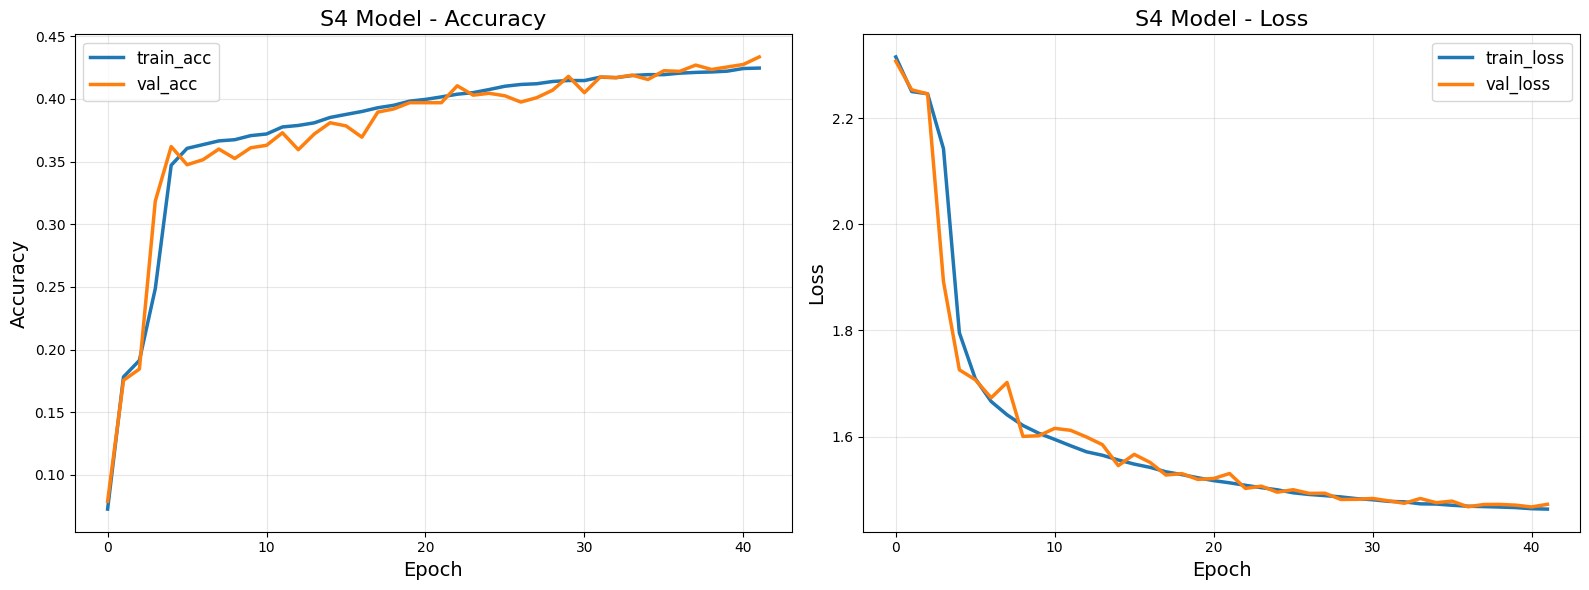

In [6]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=ListOpsTask(),
)

history = trainer.history

plot_history(history, model_name="S4")

### Evaluation

After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 41
Val metrics: {'loss': 1.4726728649139404, 'time_s': 3.7877927090012236, 'acc': 0.4334999995231628}
ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)

✅ Test results saved to: runs/listops_s4_task/test_results.json

   Test Accuracy: 0.4235 (42.35%)
   Test Loss: 1.4728

TEST SET RESULTS
Overall accuracy: 0.4235
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_0                   : 0.848
02. class_9                   : 0.803
03. class_4                   : 0.280
04. class_1                   : 0.268
05. class_8                   : 0.204
06. class_6       

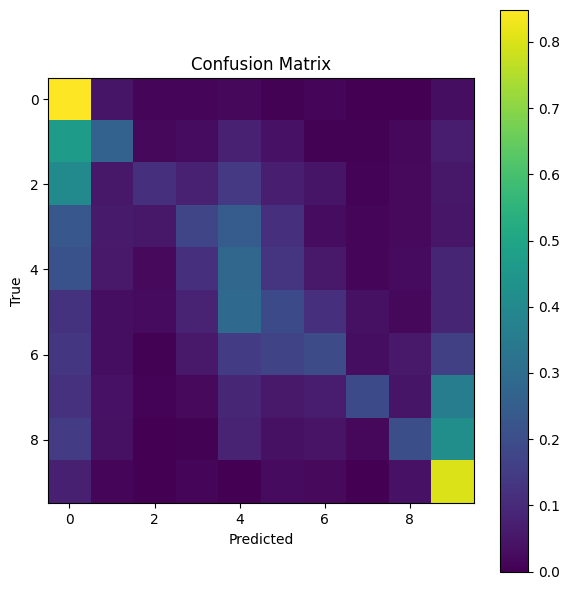

In [7]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=ListOpsTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=10,
    use_test_set=True,
)

### Training with Different Dataset Fractions

This cell demonstrates training with different fractions of the training data
to see how model performance scales with dataset size.


Training with fraction: 0.25
ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
   Applying data fraction: 25.0%
   Original train size: 96000
   Original val size: 2000
   Reduced train size: 23997
   Reduced val size: 2000
   Test size: 2000 (unchanged)
Using embedding layer with vocab_size=25


💾 saved best model to ./runs/listops_s4_task_frac_25/best.pt
✅ new best acc 0.0860
Epoch 000/50 | train 2.3268/0.0849 | val 2.3282/0.0860 | t 129.9s/3.1s | lr 1.00e-06


💾 saved best model to ./runs/listops_s4_task_frac_25/best.pt
✅ new best acc 0.1595
Epoch 001/50 | train 2.2569/0.1613 | val 2.2565/0.1595 | t 132.5s/3.3s | lr 2.01e-04


Epoch 002/50 | train 2.2501/0.1725 | val 2.2559/0.1595 | t 135.0s/3.3s | lr 4.01e-04


💾 saved best model to ./runs/listops_s4_task_frac_25/best.pt
✅ new best acc 0.1735
Epoch 003/50 | train 2.2492/0.1768 | val 2.2534/0.1735 | t 134.2s/3.3s | lr 6.00e-04


...

Epoch 038/50 | train 1.5906/0.3799 | val 1.6670/0.3605 | t 130.0s/3.2s | lr 1.65e-04


Epoch 039/50 | train 1.5894/0.3791 | val 1.6805/0.3695 | t 129.5s/3.2s | lr 1.40e-04


Epoch 040/50 | train 1.5876/0.3803 | val 1.6913/0.3660 | t 131.7s/3.3s | lr 1.17e-04


Epoch 041/50 | train 1.5854/0.3819 | val 1.6687/0.3665 | t 135.1s/3.3s | lr 9.55e-05


⏹ Early stopping (patience=10, best=0.3740).
📊 Training history saved to ./runs/listops_s4_task_frac_25/history.json

Training complete for fraction 0.25! Best validation acc: 0.3740
Best model saved to: ./runs/listops_s4_task_frac_25/best.pt


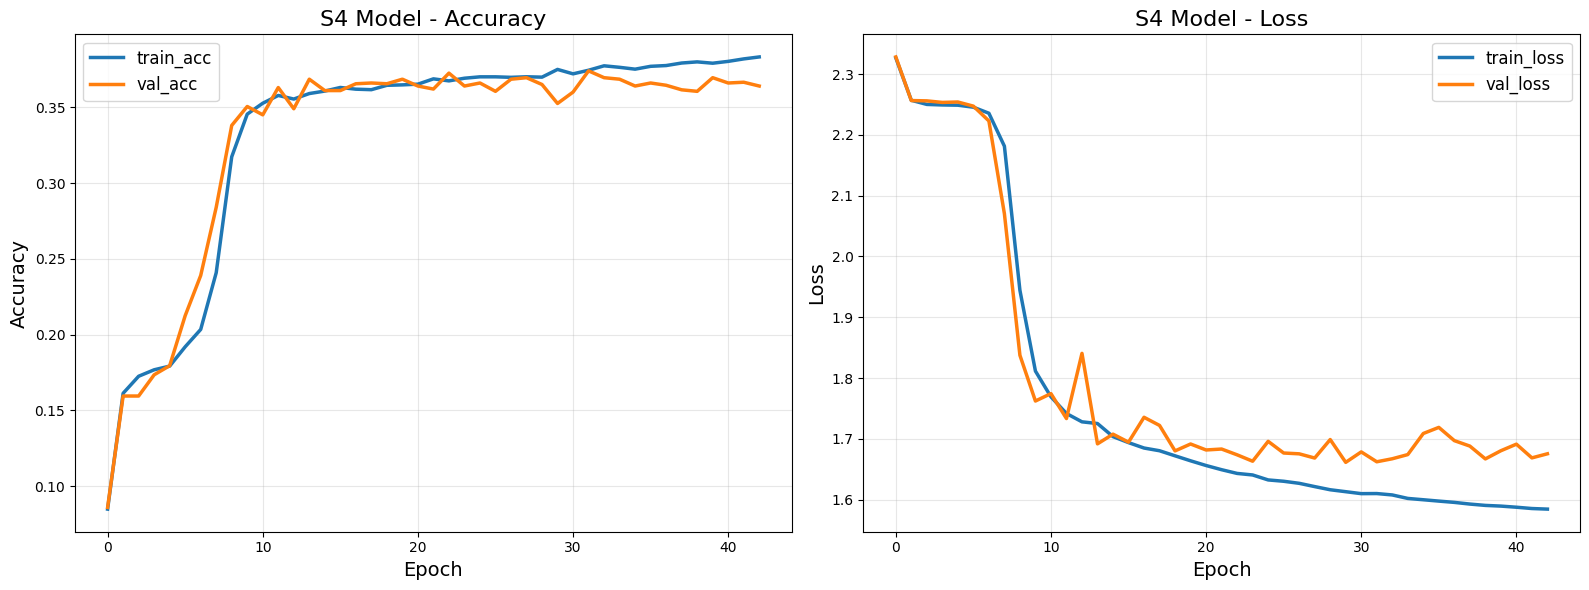

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
   Applying data fraction: 25.0%
   Original train size: 96000
   Original val size: 2000
   Reduced train size: 23997
   Reduced val size: 2000
   Test size: 2000 (unchanged)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 31
Val metrics: {'loss': 1.6623269729614258, 'time_s': 4.695615540999825, 'acc': 0.37400000023841856}
ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)

✅ Test results saved to: runs/listops_s4_task_frac_25/test_results.json

   Test Accuracy: 0.3755 (37.55%)
   Test Loss: 1.6402

TEST SET RESULTS
Overall accuracy: 0.3755
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_0             

💾 saved best model to ./runs/listops_s4_task_frac_50/best.pt
✅ new best acc 0.0875
Epoch 000/50 | train 2.3293/0.0771 | val 2.3147/0.0875 | t 270.3s/3.4s | lr 1.00e-06


💾 saved best model to ./runs/listops_s4_task_frac_50/best.pt
✅ new best acc 0.1900
Epoch 001/50 | train 2.2529/0.1700 | val 2.2549/0.1900 | t 278.9s/3.3s | lr 2.01e-04


Epoch 002/50 | train 2.2490/0.1753 | val 2.2535/0.1720 | t 280.1s/3.4s | lr 4.01e-04


Epoch 003/50 | train 2.2469/0.1896 | val 2.2519/0.1715 | t 282.1s/3.4s | lr 6.00e-04


...

Epoch 028/50 | train 1.5713/0.3823 | val 1.5892/0.3645 | t 294.7s/3.6s | lr 4.83e-04


Epoch 029/50 | train 1.5677/0.3831 | val 1.5976/0.3780 | t 293.3s/3.5s | lr 4.48e-04


Epoch 030/50 | train 1.5637/0.3855 | val 1.5832/0.3680 | t 294.4s/3.6s | lr 4.13e-04


Epoch 031/50 | train 1.5633/0.3853 | val 1.5873/0.3735 | t 398.7s/5.3s | lr 3.79e-04


⏹ Early stopping (patience=10, best=0.3770).
📊 Training history saved to ./runs/listops_s4_task_frac_50/history.json

Training complete for fraction 0.5! Best validation acc: 0.3770
Best model saved to: ./runs/listops_s4_task_frac_50/best.pt


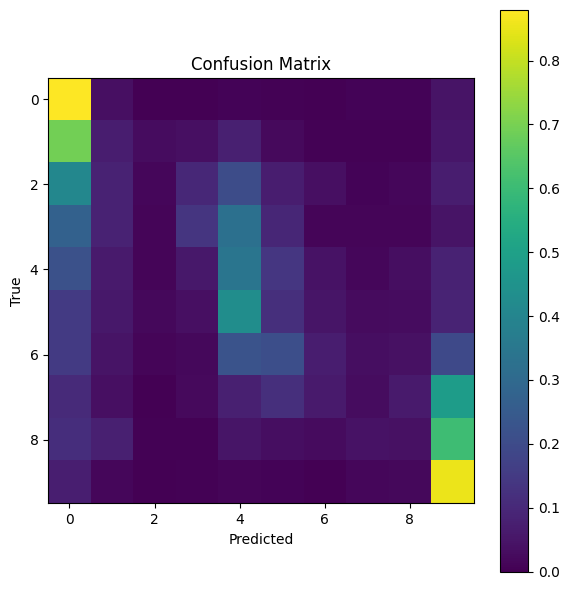

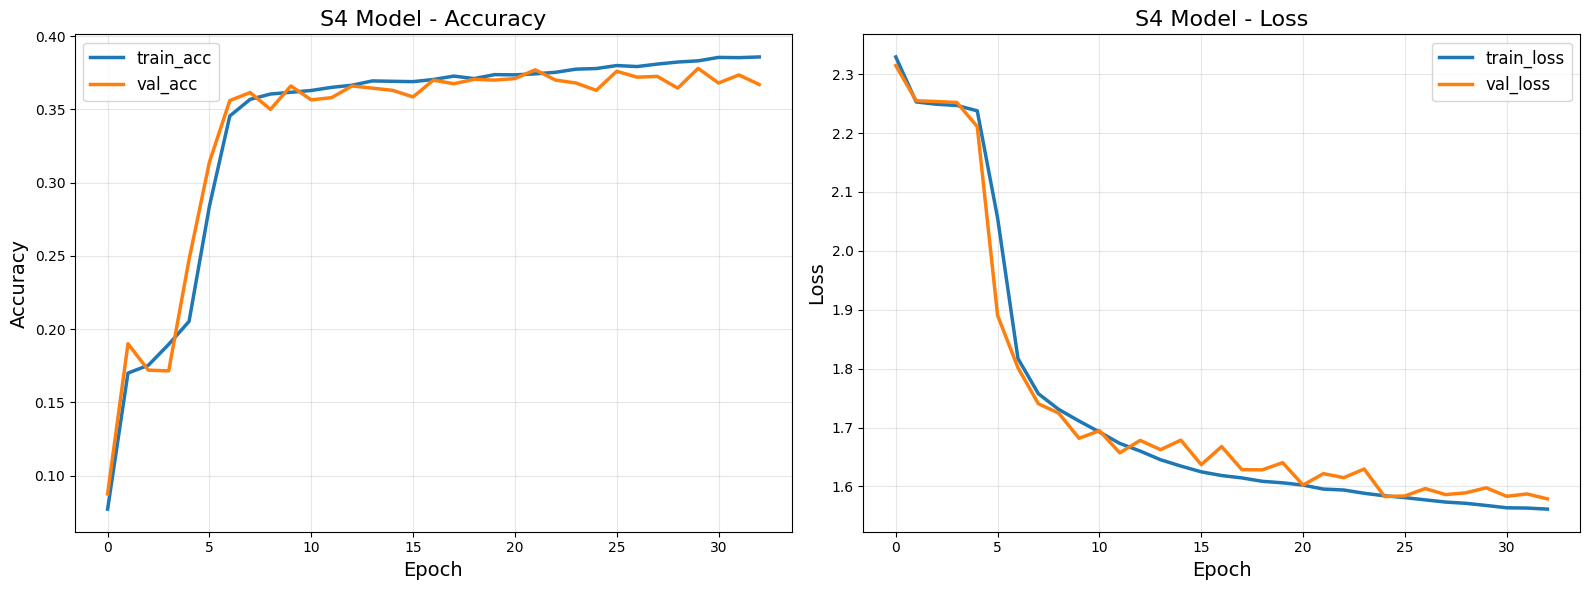

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
   Applying data fraction: 50.0%
   Original train size: 96000
   Original val size: 2000
   Reduced train size: 47997
   Reduced val size: 2000
   Test size: 2000 (unchanged)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 21
Val metrics: {'loss': 1.6217044897079467, 'time_s': 3.5820669590011676, 'acc': 0.3770000004768372}
ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)

✅ Test results saved to: runs/listops_s4_task_frac_50/test_results.json

   Test Accuracy: 0.3800 (38.00%)
   Test Loss: 1.6090

TEST SET RESULTS
Overall accuracy: 0.3800
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_9             

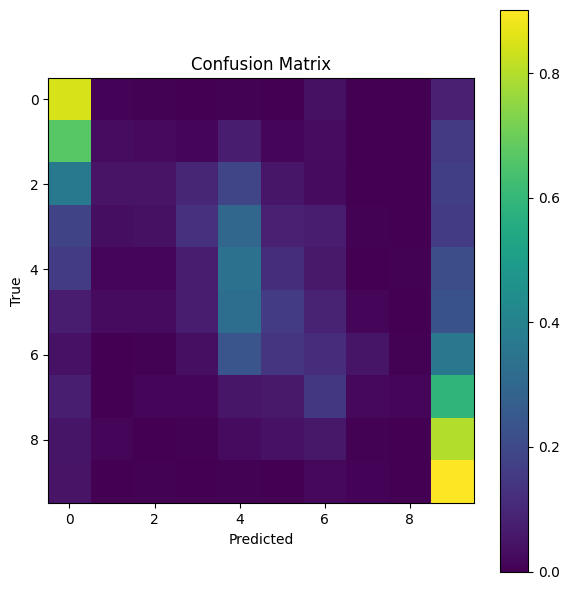

In [9]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/listops_s4_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=ListOpsTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history
    plot_history(history, model_name="S4")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=ListOpsTask(),
        best_model_path=best_path,
        num_classes=10,
        use_test_set=True,
    )